Variance of Machine A = 0.1210
Variance of Machine B = 0.0090
F statistic  = 13.4444 (df1 = 9, df2 = 9)
F critical   = 4.0260
p-value      = 0.000653

Decision: Reject H0 -> The variances are different. Machine A is less consistent.


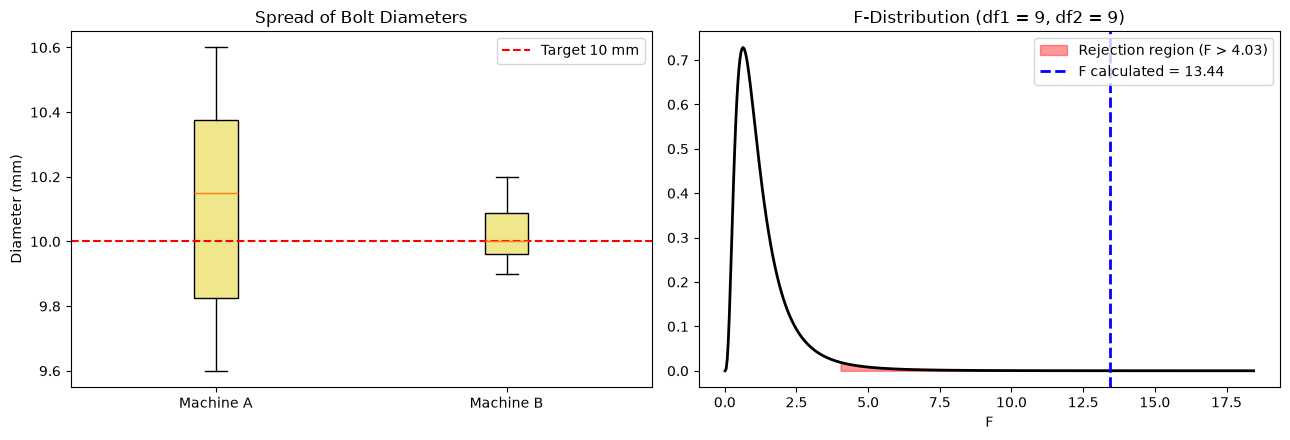

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Data - bolt diameters (mm)
machine_A = np.array([
    10.2, 9.8, 10.5, 9.6, 10.4,
    9.9, 10.6, 9.7, 10.3, 10.1
])

machine_B = np.array([
    10.0, 10.1, 9.9, 10.0, 10.2,
    9.95, 10.05, 10.1, 9.9, 10.0
])

alpha = 0.05

# Step 2: Sample variances
var_A = np.var(machine_A, ddof=1)
var_B = np.var(machine_B, ddof=1)

# Step 3: F statistic
# Larger variance / smaller variance
if var_A >= var_B:
    F = var_A / var_B
    df1 = len(machine_A) - 1
    df2 = len(machine_B) - 1
else:
    F = var_B / var_A
    df1 = len(machine_B) - 1
    df2 = len(machine_A) - 1

# Two-tailed test
p_value = 2 * (1 - stats.f.cdf(F, df1, df2))

F_critical = stats.f.ppf(
    1 - alpha / 2,
    df1,
    df2
)

print(f"Variance of Machine A = {var_A:.4f}")
print(f"Variance of Machine B = {var_B:.4f}")
print(f"F statistic  = {F:.4f} (df1 = {df1}, df2 = {df2})")
print(f"F critical   = {F_critical:.4f}")
print(f"p-value      = {p_value:.6f}")

# Step 4: Decision
if F > F_critical:
    print(
        "\nDecision: Reject H0 -> "
        "The variances are different. Machine A is less consistent."
    )
else:
    print(
        "\nDecision: Fail to reject H0 -> "
        "Both machines have similar variability."
    )

# Step 5: Graphs
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Graph 1: Boxplot
ax[0].boxplot(
    [machine_A, machine_B],
    patch_artist=True,
    boxprops=dict(facecolor='khaki')
)

ax[0].set_xticks([1, 2])
ax[0].set_xticklabels(['Machine A', 'Machine B'])

ax[0].axhline(
    10,
    color='red',
    linestyle='--',
    label='Target 10 mm'
)

ax[0].set_title('Spread of Bolt Diameters')
ax[0].set_ylabel('Diameter (mm)')
ax[0].legend()

# Graph 2: F-distribution
x = np.linspace(
    0.01,
    max(F + 5, 8),
    500
)

y = stats.f.pdf(
    x,
    df1,
    df2
)

ax[1].plot(
    x,
    y,
    'k',
    lw=2
)

ax[1].fill_between(
    x,
    y,
    where=(x >= F_critical),
    color='red',
    alpha=0.4,
    label=f'Rejection region (F > {F_critical:.2f})'
)

ax[1].axvline(
    F,
    color='blue',
    linestyle='--',
    lw=2,
    label=f'F calculated = {F:.2f}'
)

ax[1].set_title(
    f'F-Distribution (df1 = {df1}, df2 = {df2})'
)

ax[1].set_xlabel('F')
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()